# Progetto parte 2 del corso di "Data Mining" da 12 CFU

### MODULE 3: Classification

#### Define one (or more) classification task and solve it using:
* KNN with at least two distances:
- Euclidean or Manhattan
- DTW
#### Shapelets: Analyze the shapelets retrieved
- At least one other method (rocket, muse, cnn, rnn, etc.)

---

### Informazioni Generali

* **Corso:** Data Mining
* **Università:** Università di Pisa
* **Anno Accademico:** 2024/2025

### Autore

* **Studente:** Giuseppe Muschetta
* **Matricola:** 564026

### Dataset Utilizzato

* **Nome:** Extended IMDb Dataset (Tabulare)
* **Descrizione:** Dataset tabulare contenente circa 150,000 record con informazioni relative ai titoli cinematografici.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, time, ast
import warnings
warnings.filterwarnings('ignore')

# --- IMPOSTAZIONI GLOBALI PER I GRAFICI ---
# Stile base
plt.style.use("dark_background")
sns.set_theme(
    style="darkgrid",
    context="notebook",
    palette="icefire",
    font="sans-serif",
    font_scale=1.1
)

# Aggiornamenti avanzati
plt.rcParams.update({
    # Colori e sfondi
    'figure.facecolor': '#111111',
    'axes.facecolor': '#111111',
    'savefig.facecolor': '#111111',
    'axes.edgecolor': 'white',
    'axes.labelcolor': 'white',
    'axes.titlecolor': 'white',
    'text.color': 'white',
    'xtick.color': 'lightgray',
    'ytick.color': 'lightgray',

    # Font e peso
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',

    # Griglia elegante
    'axes.grid': True,
    'grid.color': 'gray',
    'grid.linestyle': '--',
    'grid.linewidth': 0.4,
    'grid.alpha': 0.3,  # meno invasiva

    # Tick leggeri
    'xtick.direction': 'out',
    'ytick.direction': 'out',

    # Leggibilità generale
    'legend.edgecolor': 'gray',
    'legend.facecolor': '#222222',
    'legend.fontsize': 'medium',
})

print("✅ Impostazioni grafiche caricate.")


# --- CREAZIONE DIRECTORY PER I MODELLI ---
print("--- Creazione directory per i modelli ---")
models_dir = 'models_time_series_classification/'
os.makedirs(models_dir, exist_ok=True)
print(f"✅ Directory per i modelli '{models_dir}' pronta.")

# --- CREAZIONE DIRECTORY PER I PLOT ---
plots_dir = 'plots_time_series_classification/'
os.makedirs(plots_dir, exist_ok=True)
print(f"✅ Directory per i grafici '{plots_dir}' pronta.")

# --- CARICAMENTO DEL DATASET PREPARATO ---
dataset_dir = "TS_Dataset/"
dataset_name = "imdb_ts.csv"
try:
    df = pd.read_csv(os.path.join(dataset_dir, dataset_name))
    print(f"✅ Dataset preparato caricato: {df.shape[0]} righe, {df.shape[1]} colonne.")
except FileNotFoundError as e:
    print(f"❌ Errore: File non trovato. Assicurati di aver eseguito il Modulo 0 e salvato '{dataset_name}'.")
    exit(1)


✅ Impostazioni grafiche caricate.
--- Creazione directory per i modelli ---
✅ Directory per i modelli 'models_time_series_classification/' pronta.
✅ Directory per i grafici 'plots_time_series_classification/' pronta.
✅ Dataset preparato caricato: 1134 righe, 104 colonne.


#### Data cleaning and Parsing genre column

In [2]:
print("--- Distribuzione classi originale ---")
print(df['rating_category'].value_counts())

# Decisione Strategica: rimuoviamo la classe 'Low'
print("\n--- Rimozione della classe 'Low' ---")
df_clean = df[df['rating_category'] != 'Low'].copy()
print(f"Dataset ora con {df_clean.shape[0]} righe e 4 classi.")

# Parsing della colonna 'genre'
df_clean['genre'] = df_clean['genre'].apply(lambda s: ast.literal_eval(s) if isinstance(s, str) else s)
print("\n✅ Colonna 'genre' parsata correttamente.")

--- Distribuzione classi originale ---
rating_category
Medium         387
High           377
Medium High    232
Medium Low     128
Low             10
Name: count, dtype: int64

--- Rimozione della classe 'Low' ---
Dataset ora con 1124 righe e 4 classi.

✅ Colonna 'genre' parsata correttamente.


#### Definizione Features (X), Target (y) e Split

In [3]:
from sklearn.model_selection import train_test_split

# Definizione colonne e separazione X/y
ts_cols = [str(i) for i in range(100)]
X = df_clean[ts_cols]
y_str = df_clean['rating_category']

# Mapping del target a interi
class_order = ['Medium Low', 'Medium', 'Medium High', 'High']
label_mapping = {label: i for i, label in enumerate(class_order)}
y = y_str.map(label_mapping)
inv_label_mapping = {v: k for k, v in label_mapping.items()}


# Train-Test Split stratificato
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("--- Split Train-Test completato ---")
print(f"Dimensioni Training Set: {X_train.shape[0]} campioni")
print(f"Dimensioni Test Set:     {X_test.shape[0]} campioni")

--- Split Train-Test completato ---
Dimensioni Training Set: 899 campioni
Dimensioni Test Set:     225 campioni


#### Funzione di valutazione 

In [4]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score

model_results = {}

def evaluate_model(y_true, y_pred, model_name, fit_time, predict_time):
   """
   Calcola, stampa e plotta le metriche di valutazione, tenendo traccia dei tempi.
   """
   print(f"--- Valutazione Modello: {model_name} ---")

   macro_f1 = f1_score(y_true, y_pred, average='macro')
   balanced_acc = balanced_accuracy_score(y_true, y_pred)

   model_results[model_name] = {
       'Macro F1': macro_f1,
       'Balanced Accuracy': balanced_acc,
       'Fit Time (s)': fit_time,
       'Predict Time (s)': predict_time
   }

   print(f"Macro F1-Score: {macro_f1:.4f}")
   print(f"Balanced Accuracy: {balanced_acc:.4f}")
   print(f"Tempo di Fit: {fit_time:.2f}s | Tempo di Predict: {predict_time:.2f}s")
   print("\nClassification Report:")
   print(classification_report(y_true, y_pred, target_names=label_mapping.keys()))

   # Stampa testuale della matrice di confusione
   cm = confusion_matrix(y_true, y_pred)
   print("\nConfusion Matrix (testuale):")
   print("Predicted →")
   print(f"{'Actual ↓':<12}", end="")
   for label in label_mapping.keys():
       print(f"{label:<12}", end="")
   print()

   for i, actual_label in enumerate(label_mapping.keys()):
       print(f"{actual_label:<12}", end="")
       for j in range(len(label_mapping)):
           print(f"{cm[i,j]:<12}", end="")
       print()

   plt.figure(figsize=(8, 6))
   sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
               xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
   plt.title(f'Confusion Matrix - {model_name}')
   plt.ylabel('Classe Vera')
   plt.xlabel('Classe Predetta')
   plt.tight_layout()
   plt.savefig(os.path.join(plots_dir, f"cm_{model_name.lower().replace(' ', '_')}.png"))
   plt.show()

print("✅ Funzione di valutazione 'evaluate_model' pronta.")

✅ Funzione di valutazione 'evaluate_model' pronta.


#### Modello 1 - k-NN (Euclidean or Manhattan)

--- Modello 1: k-NN (euclidean o manhattan) con Pipeline e GridSearchCV ---
Fitting 5 folds for each of 38 candidates, totalling 190 fits
✅ Training completato in 1.70 secondi
Migliori parametri trovati: {'kneighborsclassifier__metric': 'euclidean', 'kneighborsclassifier__n_neighbors': 10}
Miglior Macro F1-Score in CV: 0.3988
--- Valutazione su Test Set ---
--- Valutazione Modello: k-NN (Pipeline) ---
Macro F1-Score: 0.3702
Balanced Accuracy: 0.3786
Tempo di Fit: 1.70s | Tempo di Predict: 0.03s

Classification Report:
              precision    recall  f1-score   support

  Medium Low       0.29      0.19      0.23        26
      Medium       0.43      0.67      0.52        78
 Medium High       0.28      0.11      0.16        46
        High       0.59      0.55      0.57        75

    accuracy                           0.46       225
   macro avg       0.40      0.38      0.37       225
weighted avg       0.44      0.46      0.43       225


Confusion Matrix (testuale):
Predicted →

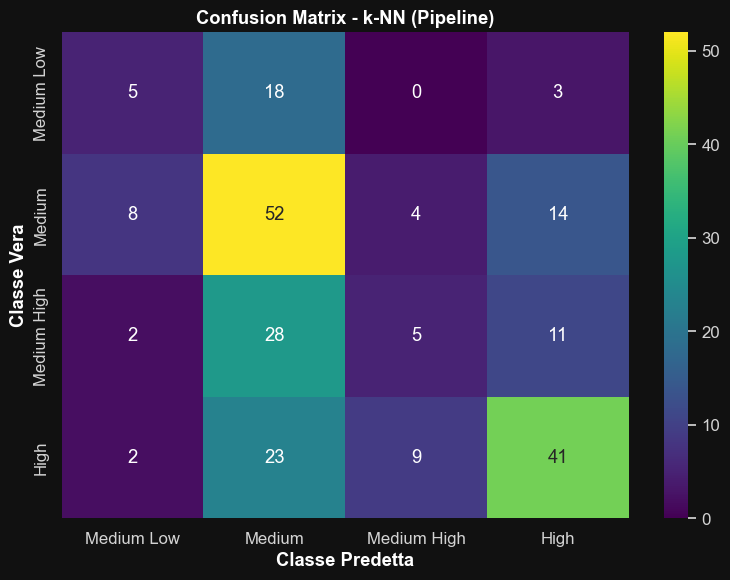

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

print("--- Modello 1: k-NN (euclidean o manhattan) con Pipeline e GridSearchCV ---")

# Costruiamo la pipeline
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('kneighborsclassifier', KNeighborsClassifier())
])

# Griglia iperparametri
param_grid_knn = {
    'kneighborsclassifier__n_neighbors': list(range(1, 20)),  # da 1 a 11
    'kneighborsclassifier__metric': ['euclidean', 'manhattan']
}

# Setup GridSearchCV
grid_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_grid_knn,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

# Training
start_time = time.time()
grid_knn.fit(X_train, y_train)
fit_time_knn = time.time() - start_time
best_knn_pipe = grid_knn.best_estimator_

# Log risultati
print(f"✅ Training completato in {fit_time_knn:.2f} secondi")
print(f"Migliori parametri trovati: {grid_knn.best_params_}")
print(f"Miglior Macro F1-Score in CV: {grid_knn.best_score_:.4f}")

# Valutazione su Test Set
print("--- Valutazione su Test Set ---")
start_time = time.time()
y_pred_knn = best_knn_pipe.predict(X_test)
predict_time_knn = time.time() - start_time

evaluate_model(y_test, y_pred_knn, 'k-NN (Pipeline)', fit_time_knn, predict_time_knn)


#### Modello 2 KNN con DTW

--- Modello 2: k-NN (DTW) con GridSearchCV ---
✅ Setup di GridSearchCV per k-NN (DTW) completato.
--- Avvio del training di GridSearchCV per k-NN (DTW)... (potrebbe richiedere tempo) ---
Fitting 5 folds for each of 6 candidates, totalling 30 fits
--- Training completato in 182.40 secondi ---
Migliori parametri trovati: {'n_neighbors': 7}
Miglior Macro F1-Score in CV: 0.3669
--- Valutazione Modello: k-NN (DTW) ---
Macro F1-Score: 0.3466
Balanced Accuracy: 0.3600
Tempo di Fit: 182.40s | Tempo di Predict: 60.04s

Classification Report:
              precision    recall  f1-score   support

  Medium Low       0.26      0.27      0.26        26
      Medium       0.43      0.69      0.53        78
 Medium High       0.12      0.07      0.08        46
        High       0.66      0.41      0.51        75

    accuracy                           0.42       225
   macro avg       0.37      0.36      0.35       225
weighted avg       0.42      0.42      0.40       225


Confusion Matrix (testual

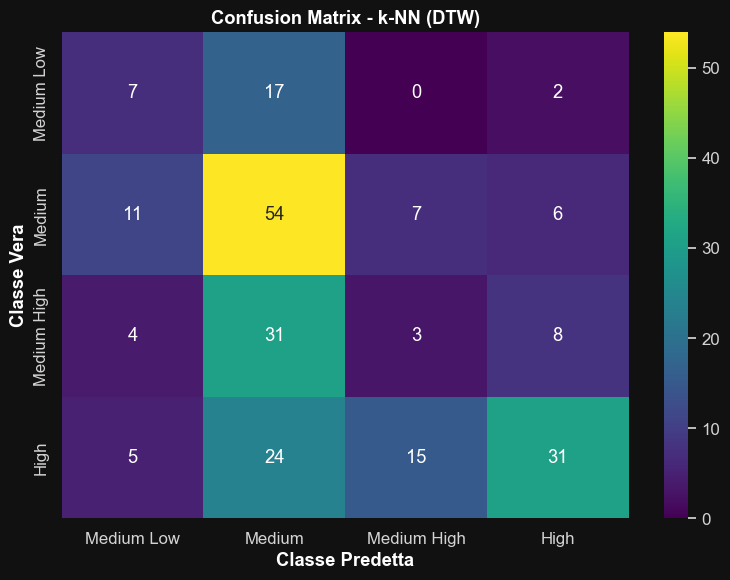

In [6]:
from tslearn.neighbors import KNeighborsTimeSeriesClassifier

print("--- Modello 2: k-NN (DTW) con GridSearchCV ---")

# Non serve una pipeline perché DTW non richiede scaling
knn_dtw = KNeighborsTimeSeriesClassifier(metric='dtw')
param_grid_dtw = {'n_neighbors': list(range(7, 13))}

grid_dtw = GridSearchCV(
    estimator=knn_dtw,
    param_grid=param_grid_dtw,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
print("✅ Setup di GridSearchCV per k-NN (DTW) completato.")

print("--- Avvio del training di GridSearchCV per k-NN (DTW)... (potrebbe richiedere tempo) ---")
start_time = time.time()
grid_dtw.fit(X_train.values, y_train.values)
fit_time_dtw = time.time() - start_time
print(f"--- Training completato in {fit_time_dtw:.2f} secondi ---")

print(f"Migliori parametri trovati: {grid_dtw.best_params_}")
print(f"Miglior Macro F1-Score in CV: {grid_dtw.best_score_:.4f}")

best_dtw = grid_dtw.best_estimator_

# DTW ha un inference time non trascurabile
start_time = time.time()
y_pred_dtw = best_dtw.predict(X_test.values)
predict_time_dtw = time.time() - start_time

evaluate_model(y_test, y_pred_dtw, 'k-NN (DTW)', fit_time_dtw, predict_time_dtw)


#### Modello 3 - Shapelet Model

--- Modello 3 • ShapeletModel (SoTA) ---


2025-08-01 19:40:25.018942: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-08-01 19:40:25.018995: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-08-01 19:40:25.019000: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
2025-08-01 19:40:25.019356: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-08-01 19:40:25.019369: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/1000


2025-08-01 19:41:49.187925: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - categorical_accuracy: 0.2565 - categorical_crossentropy: 1.3793 - loss: 1.3799
Epoch 2/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - categorical_accuracy: 0.3813 - categorical_crossentropy: 1.3724 - loss: 1.3730
Epoch 3/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - categorical_accuracy: 0.4229 - categorical_crossentropy: 1.3661 - loss: 1.3667
Epoch 4/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - categorical_accuracy: 0.4286 - categorical_crossentropy: 1.3600 - loss: 1.3607
Epoch 5/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - categorical_accuracy: 0.4315 - categorical_crossentropy: 1.3543 - loss: 1.3549
Epoch 6/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - categorical_accuracy: 0.4326 - categorical_crossentropy: 1.3488 - loss: 1.3494
Epoch 7/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - categorical_accuracy: 0.4385 - categorical_crossentropy: 1.3434 - loss: 1.3441
Epoch 8/1000
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - categorical_accuracy

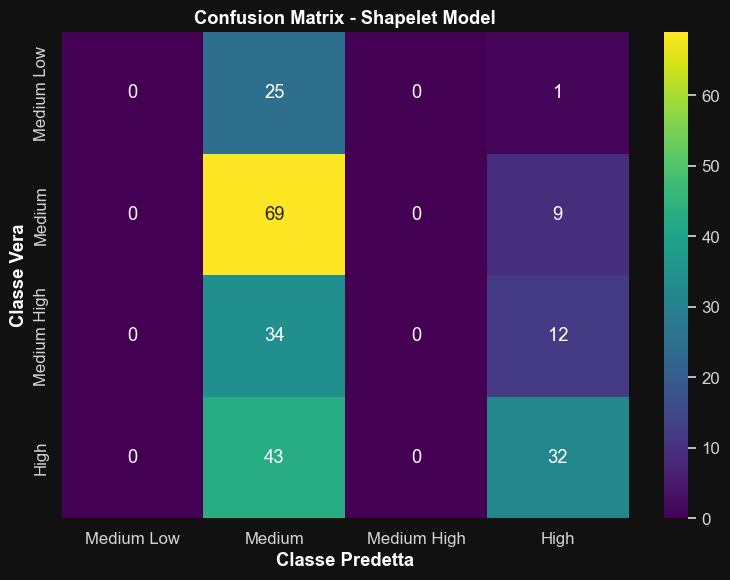

In [7]:
# ---------------------------------- SHAPELET MODEL SOTA ----------------------------------
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.shapelets import ShapeletModel
import numpy as np, time

print("--- Modello 3 • ShapeletModel (SoTA) ---")

# 1) Normalizzazione per serie (μ=0, σ=1) con la classe tslearn
scaler = TimeSeriesScalerMeanVariance(mu=0., std=1.)
X_train_z = scaler.fit_transform(X_train.values.astype(np.float32))
X_test_z  = scaler.transform(X_test.values.astype(np.float32))

# 2) Costruzione del modello
shp_model = ShapeletModel(
    n_shapelets_per_size=None,
    max_iter=1000,                # epoche ragionevoli
    batch_size=64,                # mini-batch training
    optimizer="adam",             # convergenza più stabile di SGD
    weight_regularizer=1e-4,      # lieve L2 sul layer soft-max
    scale=True,                   # min-max interno 0-1 (aiuta il gradiente): contentReference[oaicite:1]{index=1}
    verbose=1,
    random_state=42
)

# 3) Training
t0 = time.time()
shp_model.fit(X_train_z, y_train.values)
fit_time_shp = time.time() - t0
print(f"✅ Training completato in {fit_time_shp:.2f}s")

# 4) Predizione e valutazione
t0 = time.time()
y_pred_shp = shp_model.predict(X_test_z)
predict_time_shp = time.time() - t0

evaluate_model(
    y_test,
    y_pred_shp,
    model_name='Shapelet Model',
    fit_time=fit_time_shp,
    predict_time=predict_time_shp
)


#### Analisi shapelet estratti

--- Visualizzazione Shapelet Chiave ---
Shapelet estratti: 15


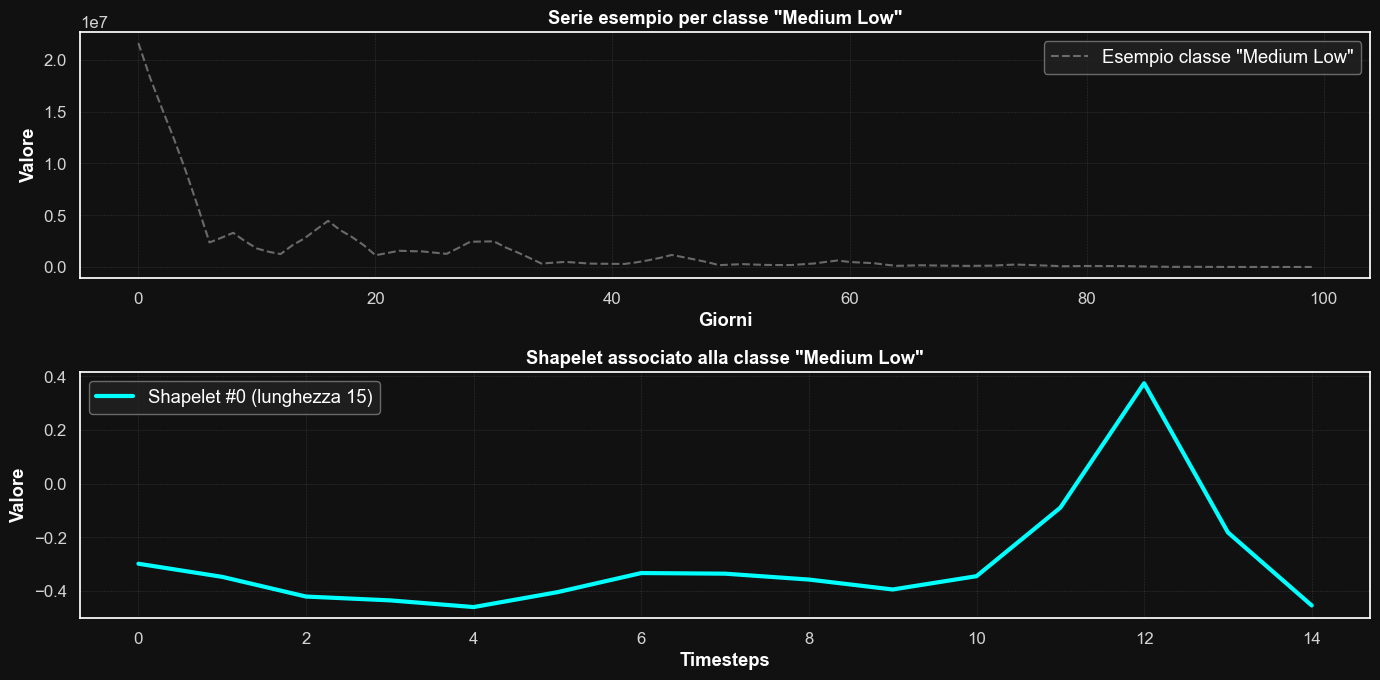

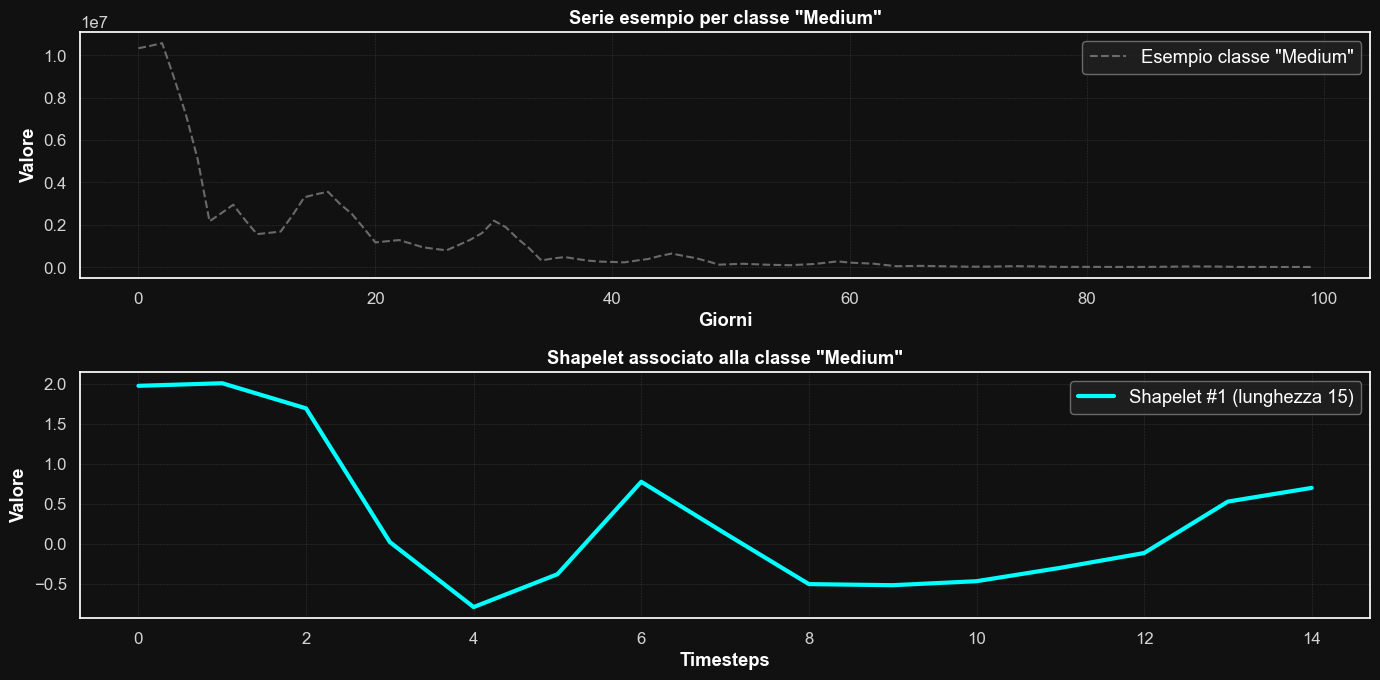

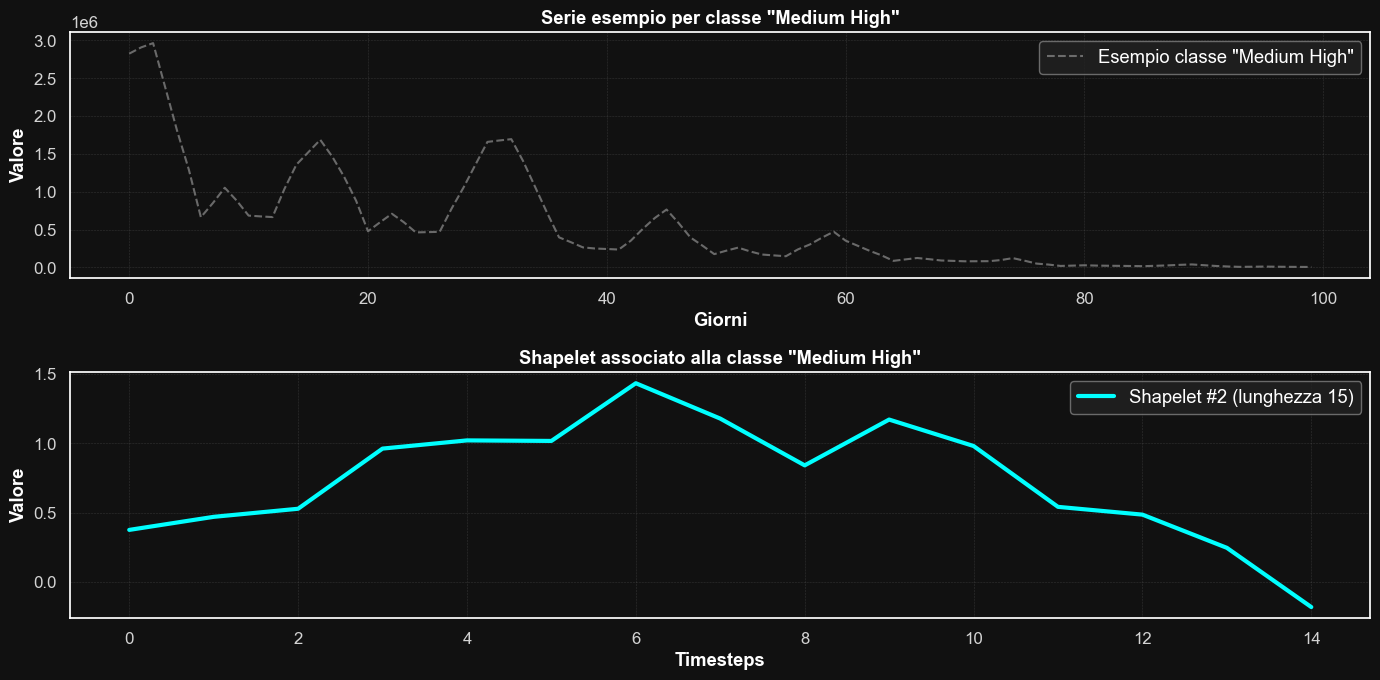

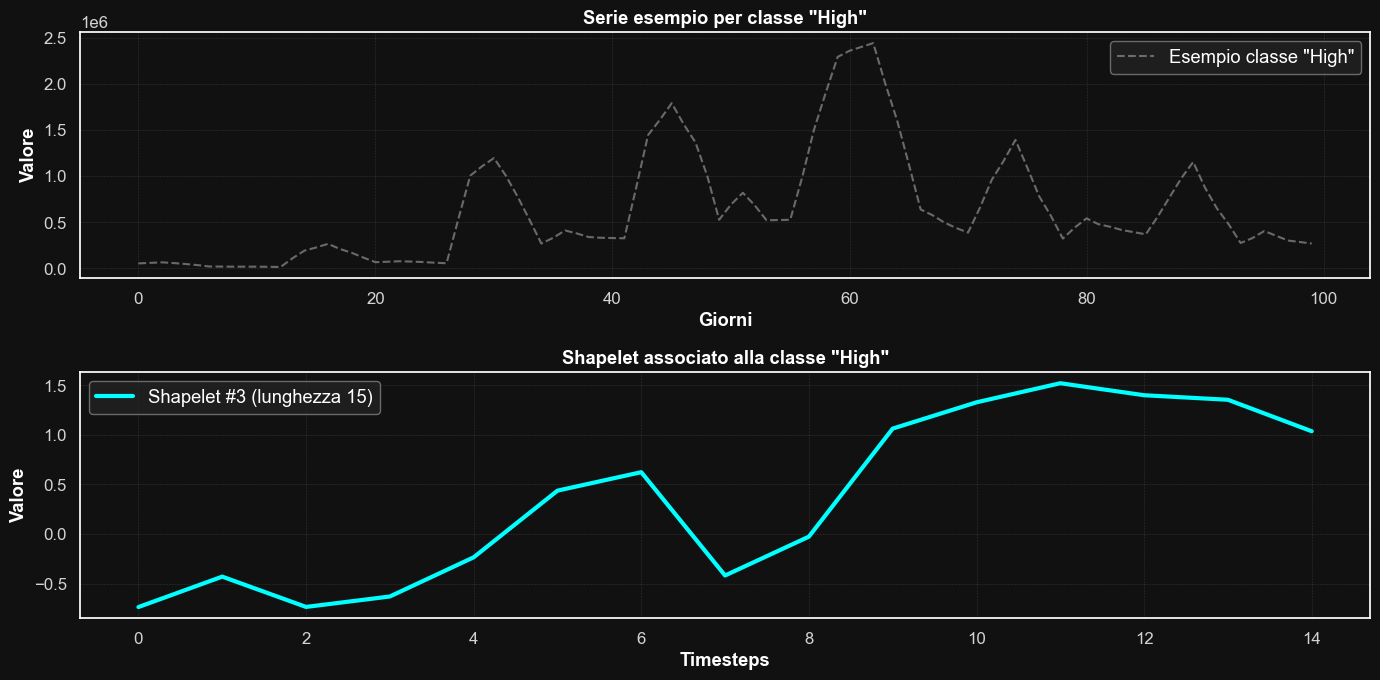

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tslearn.utils import to_time_series_dataset
import os

print("--- Visualizzazione Shapelet Chiave ---")

# Fix: Accesso corretto agli shapelet in tslearn moderno
try:
   # Estraiamo solo gli shapelet (coefficienti non sempre disponibili)
   shapelets = shp_model.shapelets_
   n_shapelets = len(shapelets)
   print(f"Shapelet estratti: {n_shapelets}")

   # Per ogni classe, prendiamo il primo shapelet disponibile (semplificato)
   shapelet_per_class = min(n_shapelets // len(label_mapping), 1)

   for class_idx in range(len(label_mapping)):
       class_name = inv_label_mapping[class_idx]

       # Prendiamo il primo shapelet per questa classe
       shp_idx = class_idx % n_shapelets  # Cycling tra shapelet disponibili
       shp = shapelets[shp_idx]

       # Serie di esempio per questa classe
       class_examples = X_train[y_train == class_idx]
       if len(class_examples) == 0:
           print(f"Nessun esempio per classe {class_name}")
           continue

       example_ts = class_examples.iloc[0].values

       # Plot shapelet vs serie esempio
       plt.figure(figsize=(14, 7))
       plt.subplot(2, 1, 1)
       plt.plot(example_ts, color='gray', linestyle='--', alpha=0.8,
               label=f'Esempio classe "{class_name}"')
       plt.title(f'Serie esempio per classe "{class_name}"')
       plt.xlabel('Giorni')
       plt.ylabel('Valore')
       plt.legend()

       plt.subplot(2, 1, 2)
       plt.plot(shp, color='cyan', linewidth=3,
               label=f'Shapelet #{shp_idx} (lunghezza {len(shp)})')
       plt.title(f'Shapelet associato alla classe "{class_name}"')
       plt.xlabel('Timesteps')
       plt.ylabel('Valore')
       plt.legend()

       plt.tight_layout()
       plt.savefig(os.path.join(plots_dir, f"shapelet_class_{class_name.replace(' ','_')}.png"),
                  dpi=150, bbox_inches='tight')
       plt.show()

except AttributeError as e:
   print(f"Errore accesso attributi ShapeletModel: {e}")
   print("Shapelet disponibili:")
   print([attr for attr in dir(shp_model) if not attr.startswith('_')])

#### Modello 4 -MiniROCKET

--- Modello 4: MiniROCKET ---
--- Avvio training MiniROCKET... ---
--- Training completato in 0.48 secondi ---
--- Valutazione Modello: MiniROCKET ---
Macro F1-Score: 0.4006
Balanced Accuracy: 0.4384
Tempo di Fit: 0.48s | Tempo di Predict: 0.07s

Classification Report:
              precision    recall  f1-score   support

  Medium Low       0.28      0.62      0.38        26
      Medium       0.44      0.47      0.46        78
 Medium High       0.27      0.13      0.18        46
        High       0.66      0.53      0.59        75

    accuracy                           0.44       225
   macro avg       0.41      0.44      0.40       225
weighted avg       0.46      0.44      0.43       225


Confusion Matrix (testuale):
Predicted →
Actual ↓    Medium Low  Medium      Medium High High        
Medium Low  16          9           0           1           
Medium      26          37          6           9           
Medium High 10          19          6           11          
High     

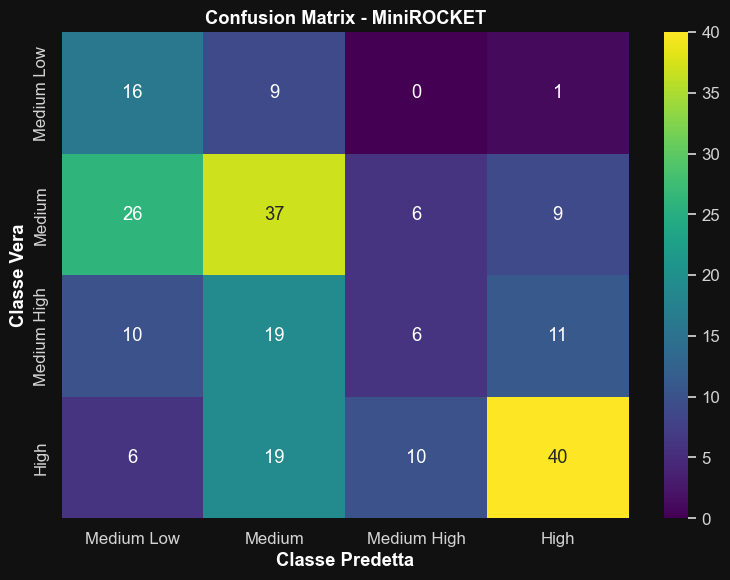

In [12]:
from sktime.transformations.panel.rocket import MiniRocket
from sklearn.linear_model import RidgeClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import Pipeline
import numpy as np
import time

# Fix: Converti in formato sktime compatibile
# Opzione 1: Reset index e converti a numpy3D
X_train_rocket = X_train.values.reshape(len(X_train), 1, -1)  # (n_samples, n_dims, n_timesteps)
X_test_rocket = X_test.values.reshape(len(X_test), 1, -1)

print("--- Modello 4: MiniROCKET ---")

rocket_pipe = Pipeline([
    ('minirocket', MiniRocket(random_state=42)),
    ('ridge', RidgeClassifierCV(alphas=np.logspace(-3, 3, 10), class_weight='balanced'))
])

print("--- Avvio training MiniROCKET... ---")
start_time = time.time()
rocket_pipe.fit(X_train_rocket, y_train)
fit_time_rocket = time.time() - start_time
print(f"--- Training completato in {fit_time_rocket:.2f} secondi ---")

start_time = time.time()
y_pred_rocket = rocket_pipe.predict(X_test_rocket)
predict_time_rocket = time.time() - start_time

evaluate_model(y_test, y_pred_rocket, 'MiniROCKET', fit_time_rocket, predict_time_rocket)


#### Confronto Finale dei Modelli

--- Tabella Comparativa dei Modelli ---


,Macro F1,Balanced Accuracy,Fit Time (s),Predict Time (s)
MiniROCKET,0.400612,0.438378,0.477626,0.068926
k-NN (Pipeline),0.370216,0.378584,1.697358,0.031936
k-NN (DTW),0.346567,0.360022,182.400756,60.039794
Shapelet Model,0.262585,0.327821,296.549925,0.619317


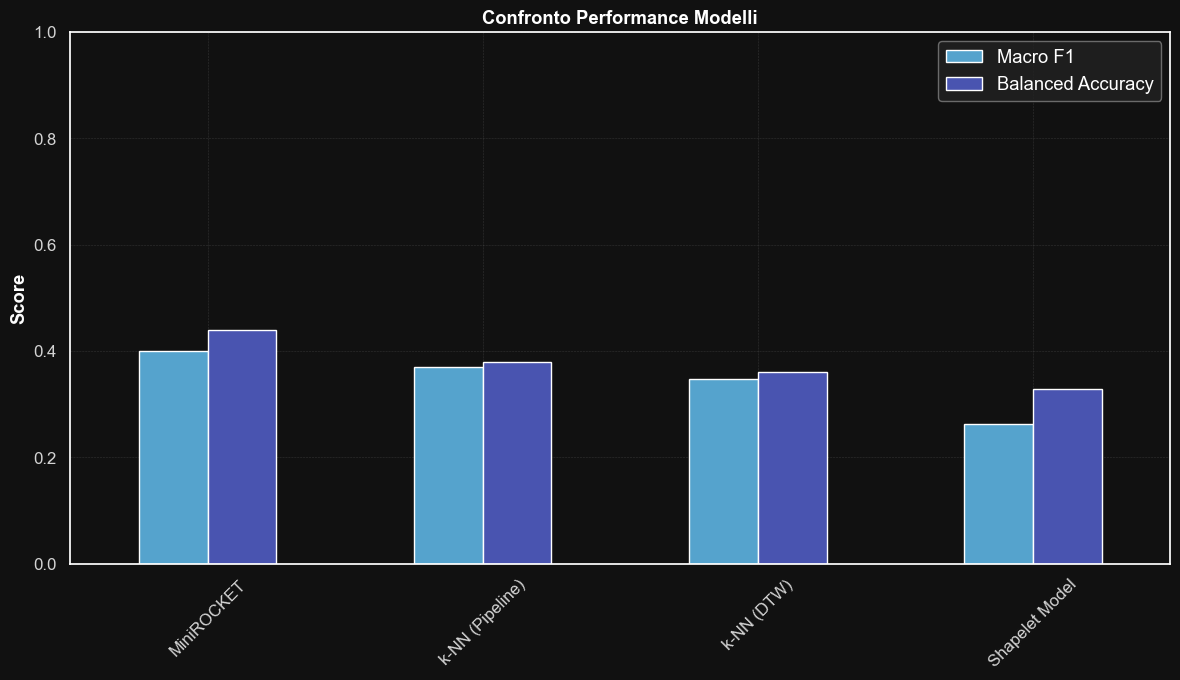

In [13]:
results_df = pd.DataFrame.from_dict(model_results, orient='index')
results_df = results_df.sort_values(by='Macro F1', ascending=False)

print("--- Tabella Comparativa dei Modelli ---")
display(results_df)

# Plot comparativo
results_df[['Macro F1', 'Balanced Accuracy']].plot(
    kind='bar',
    figsize=(12, 7),
    title='Confronto Performance Modelli',
    rot=45,
    grid=True
)
plt.ylabel('Score')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "model_comparison.png"))
plt.show()

In [14]:
print(results_df)

                 Macro F1  Balanced Accuracy  Fit Time (s)  Predict Time (s)
MiniROCKET       0.400612           0.438378      0.477626          0.068926
k-NN (Pipeline)  0.370216           0.378584      1.697358          0.031936
k-NN (DTW)       0.346567           0.360022    182.400756         60.039794
Shapelet Model   0.262585           0.327821    296.549925          0.619317
